In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

class CGBPortfolioValuation:
    def __init__(self, file_path):
        """初始化估值模型"""
        self.file_path = file_path
        self.bonds_df = None
        self.yield_curve_df = None
        
    def load_data(self):
        """加载数据"""
        try:
            # 读取个券数据（第一个sheet）
            self.bonds_df = pd.read_excel(self.file_path, sheet_name=0)
            print("个券数据加载成功，形状:", self.bonds_df.shape)
            
            # 读取收益率曲线数据（第二个sheet）
            self.yield_curve_df = pd.read_excel(self.file_path, sheet_name=1)
            print("收益率曲线数据加载成功，形状:", self.yield_curve_df.shape)
            
            # 显示数据前几行
            print("\n个券数据前3行:")
            print(self.bonds_df.head(3))
            print("\n收益率曲线数据前3行:")
            print(self.yield_curve_df.head(3))
            
        except Exception as e:
            print(f"数据加载错误: {e}")
    
    def preprocess_data(self):
        """数据预处理"""
        # 清理个券数据
        if '本金金额（百万）' in self.bonds_df.columns:
            self.bonds_df['面值'] = abs(self.bonds_df['本金金额（百万）']) * 1000000  # 转换为元
        
        # 转换日期列
        date_columns = ['起息日期', '到期日期']
        for col in date_columns:
            if col in self.bonds_df.columns:
                self.bonds_df[col] = pd.to_datetime(self.bonds_df[col])
        
        # 清理收益率曲线数据
        # 假设列名为: 日期, 标准期限说明, 标准期限(年), 收益率(%)
        if '收益率(%)' in self.yield_curve_df.columns:
            self.yield_curve_df['收益率'] = self.yield_curve_df['收益率(%)'] / 100
        
        print("数据预处理完成")
    
    def create_yield_curve_function(self, valuation_date):
        """创建收益率曲线的插值函数"""
        # 选择特定日期的收益率曲线数据
        curve_data = self.yield_curve_df.copy()
        
        # 创建期限-收益率的插值函数
        tenors = curve_data['标准期限(年)'].values
        yields = curve_data['收益率'].values
        
        # 使用线性插值
        yield_curve_func = interp1d(
            tenors, yields, 
            kind='linear', 
            fill_value='extrapolate',
            bounds_error=False
        )
        
        return yield_curve_func
    
    def calculate_bond_cash_flows(self, bond_data, valuation_date):
        """计算债券的现金流"""
        maturity_date = bond_data['到期日期']
        coupon_rate = bond_data['票据利率（发行时）'] / 100
        face_value = bond_data.get('面值', 1000000)  # 默认100万
        payment_freq = bond_data.get('每年付息次数', 1)
        
        # 计算剩余期限（年）
        remaining_years = (maturity_date - valuation_date).days / 365.25
        
        if remaining_years <= 0:
            return [], []  # 已到期债券
        
        # 生成现金流时间点
        cash_flows = []
        time_points = []
        
        # 计算付息次数
        num_payments = int(remaining_years * payment_freq)
        
        for i in range(1, num_payments + 1):
            payment_time = i / payment_freq  # 年
            if payment_time <= remaining_years:
                cash_flows.append(face_value * coupon_rate / payment_freq)
                time_points.append(payment_time)
        
        # 最后一次现金流包括本金
        if num_payments > 0:
            cash_flows[-1] += face_value
        
        return cash_flows, time_points
    
    def value_single_bond(self, bond_data, valuation_date, yield_curve_func):
        """估值单只债券"""
        try:
            # 计算现金流
            cash_flows, time_points = self.calculate_bond_cash_flows(bond_data, valuation_date)
            
            if not cash_flows:
                return 0  # 已到期债券价值为0
            
            # 计算现值
            present_value = 0
            for cf, time in zip(cash_flows, time_points):
                # 获取对应期限的收益率
                ytm = yield_curve_func(time)
                # 贴现
                discount_factor = 1 / (1 + ytm) ** time
                present_value += cf * discount_factor
            
            return present_value
            
        except Exception as e:
            print(f"债券估值错误 {bond_data.get('证券简称', '未知')}: {e}")
            return 0
    
    def value_portfolio_2020(self):
        """计算2020年投资组合价值"""
        if self.bonds_df is None or self.yield_curve_df is None:
            print("请先加载数据")
            return None
        
        # 生成2020年的月度估值日期
        valuation_dates = pd.date_range('2020-01-31', '2020-12-31', freq='M')
        
        portfolio_values = []
        
        for date in valuation_dates:
            print(f"正在计算 {date.strftime('%Y-%m-%d')} 的组合价值...")
            
            # 创建该日期的收益率曲线函数
            yield_curve_func = self.create_yield_curve_function(date)
            
            # 计算组合总价值
            total_value = 0
            bond_values = []
            
            for idx, bond in self.bonds_df.iterrows():
                bond_pv = self.value_single_bond(bond, date, yield_curve_func)
                total_value += bond_pv
                bond_values.append({
                    '债券代码': bond['证券代码'],
                    '债券简称': bond['证券简称'],
                    '现值': bond_pv
                })
            
            portfolio_values.append({
                '日期': date,
                '组合价值': total_value,
                '债券明细': bond_values
            })
        
        return portfolio_values
    
    def generate_valuation_report(self, portfolio_values):
        """生成估值报告"""
        # 提取时间序列数据
        dates = [pv['日期'] for pv in portfolio_values]
        values = [pv['组合价值'] for pv in portfolio_values]
        
        # 创建结果DataFrame
        result_df = pd.DataFrame({
            '日期': dates,
            '组合价值(元)': values
        })
        
        # 绘制组合价值走势图
        plt.figure(figsize=(12, 6))
        plt.plot(dates, values, 'b-o', linewidth=2, markersize=6)
        plt.title('CGB投资组合价值走势 - 2020年', fontsize=14)
        plt.xlabel('日期', fontsize=12)
        plt.ylabel('组合价值 (元)', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # 显示统计信息
        print("\n=== 投资组合估值统计 ===")
        print(f"估值期间: 2020年1月 - 2020年12月")
        print(f"初始价值: {values[0]:,.2f} 元")
        print(f"期末价值: {values[-1]:,.2f} 元")
        print(f"平均价值: {np.mean(values):,.2f} 元")
        print(f"最大价值: {np.max(values):,.2f} 元")
        print(f"最小价值: {np.min(values):,.2f} 元")
        print(f"价值波动: {(values[-1] - values[0]) / values[0] * 100:.2f}%")
        
        return result_df

个券数据加载成功，形状: (8, 12)
收益率曲线数据加载成功，形状: (4233, 4)

个券数据前3行:
        证券代码      证券简称        起息日期  债券期限(年)\n\n[单位] 年  利率类型  \
0  180001.IB  18附息国债01  2018-01-18                5.0  固定利率   
1  180005.IB  18附息国债05  2018-03-08                7.0  固定利率   
2  180019.IB  18附息国债19  2018-08-16               10.0  固定利率   

   票面利率(发行时)\n\n[单位] %↓ 计息方式     计息基准 息票品种        到期日期  每年付息次数  本金金额 （百万）  
0                  3.81   单利  ACT/ACT   附息  2023-01-18     1.0      -50.0  
1                  3.77   单利  ACT/ACT   附息  2025-03-08     1.0      -20.0  
2                  3.54   单利  ACT/ACT   附息  2028-08-16     2.0        5.0  

收益率曲线数据前3行:
           日期 标准期限说明  标准期限(年)  收益率(%)
0  2020-01-02     0d     0.00  1.2000
1  2020-01-02     1m     0.08  1.3442
2  2020-01-02     2m     0.17  1.8940
数据预处理完成
正在计算 2020-01-31 的组合价值...
债券估值错误 18附息国债01: '票据利率（发行时）'
债券估值错误 18附息国债05: '票据利率（发行时）'
债券估值错误 18附息国债19: '票据利率（发行时）'
债券估值错误 19附息国债03: '票据利率（发行时）'
债券估值错误 16附息国债23: '票据利率（发行时）'
债券估值错误 19附息国债02: '票据利率（发行时）'
债券估值错误 NaT: '票

/var/folders/m0/7vgjwjn979x840p_44mkhr480000gn/T/ipykernel_65576/3614584146.py:135: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  valuation_dates = pd.date_range('2020-01-31', '2020-12-31', freq='M')
/var/folders/m0/7vgjwjn979x840p_44mkhr480000gn/T/ipykernel_65576/3614584146.py:186: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  plt.tight_layout()
/var/folders/m0/7vgjwjn979x840p_44mkhr480000gn/T/ipykernel_65576/3614584146.py:186: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from current font.
  plt.tight_layout()
/var/folders/m0/7vgjwjn979x840p_44mkhr480000gn/T/ipykernel_65576/3614584146.py:186: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from current font.
  plt.tight_layout()
/var/folders/m0/7vgjwjn979x840p_44mkhr480000gn/T/ipykernel_65576/3614584146.py:186: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from current font.
  plt.

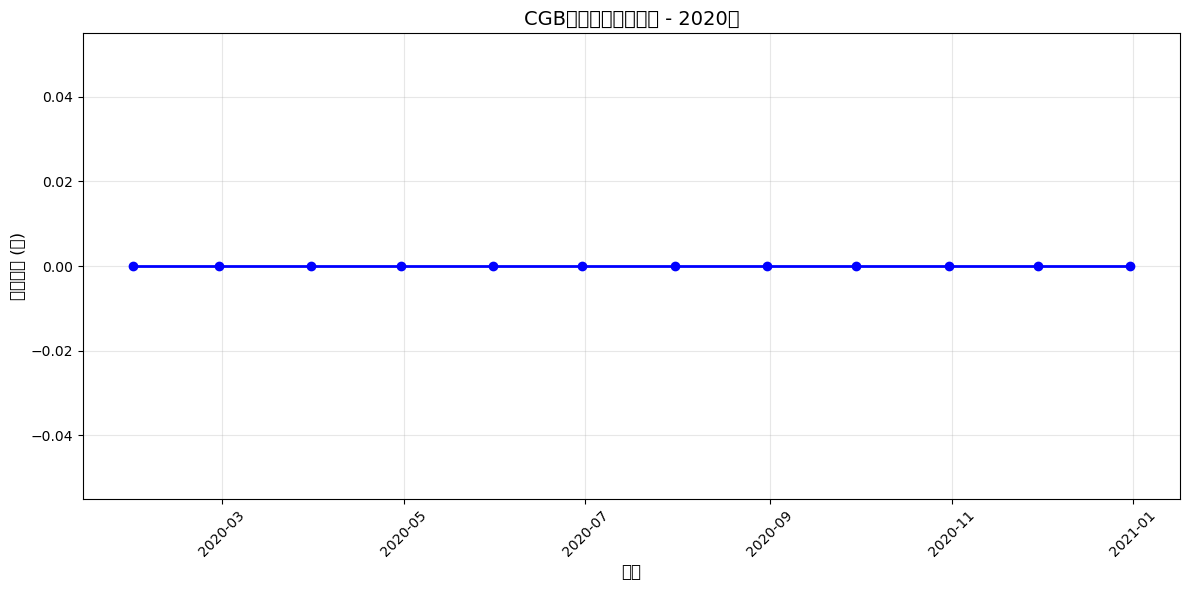


=== 投资组合估值统计 ===
估值期间: 2020年1月 - 2020年12月
初始价值: 0.00 元
期末价值: 0.00 元
平均价值: 0.00 元
最大价值: 0.00 元
最小价值: 0.00 元


ZeroDivisionError: division by zero

In [5]:
# 使用示例
def main():
    # 初始化估值器
    valuator = CGBPortfolioValuation('/Users/my/Downloads/Data set China Bond Yield Curve.xlsx')
    
    # 加载数据
    valuator.load_data()
    
    # 数据预处理
    valuator.preprocess_data()
    
    # 计算2020年组合价值
    portfolio_values = valuator.value_portfolio_2020()
    
    if portfolio_values:
        # 生成报告
        result_df = valuator.generate_valuation_report(portfolio_values)
        
        # 保存结果
        result_df.to_excel('CGB投资组合估值结果_2020.xlsx', index=False)
        print("\n估值结果已保存至: CGB投资组合估值结果_2020.xlsx")

if __name__ == "__main__":
    main()